<a href="https://colab.research.google.com/github/WahyuKhairi06/NLP_IF23/blob/main/Tugas%20Besar%20NLP/ANALISIS_SENTIMEN_ULASAN_TOKOPEDIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL LIBRARY**

In [1]:
!pip install Sastrawi
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.0 MB/s eta 0:00:00


IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

**UPLOAD DATASET**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving PRDECT-ID Dataset.csv to PRDECT-ID Dataset (1).csv


**MEMBACA DATASET**

In [4]:
df = pd.read_csv("PRDECT-ID Dataset.csv")

df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


**MELIHAT INFORMASI DATA**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


In [6]:
df.columns

Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

**MEMILIH KOLOM**

In [8]:
df = df[['Customer Review', 'Sentiment']]

df.head(25)

,Customer Review,Sentiment
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive
1,"barang bagus dan respon cepat, harga bersaing ...",Positive
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive
5,"barang bagus, seller ramah..",Positive
6,mantap paten joss,Positive
7,"Works fine. Respon seller cepat, barang berfun...",Positive
8,barang bagus.. segel.. utuh.. original.. berfu...,Positive
9,Barang datang dan berfungsi dengan baik dan te...,Positive


**MISSING VALUE**

In [9]:
df.isnull().sum()

,0
Customer Review,0
Sentiment,0


**DISTRIBUSI SENTIMEN**

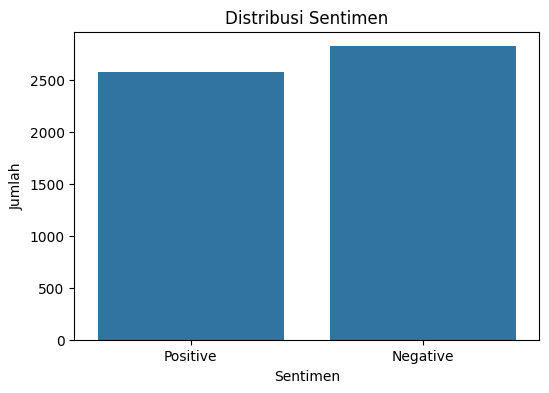

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['Sentiment']
)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")

plt.show()

**Distribusi Dataset**

In [18]:
jumlah = df['Sentiment'].value_counts()

persen = df['Sentiment'].value_counts(normalize=True) * 100

hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})

print(hasil)

           Jumlah  Persentase (%)
Sentiment                        
Negative     2821           52.24
Positive     2579           47.76


**CASE FOLDING**

In [11]:
def case_folding(text):
    text = str(text)
    text = text.lower()
    return text

df['review'] = df['Customer Review'].apply(case_folding)

**CLEANING**

In [12]:
def cleaning(text):

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    text = text.strip()

    return text

df['review'] = df['review'].apply(cleaning)

**TOKENIZING**

In [13]:
def tokenizing(text):
    return text.split()

df['tokens'] = df['review'].apply(tokenizing)

**STOPWORD REMOVAL**


In [14]:
factory = StopWordRemoverFactory()

stopwords = set(factory.get_stop_words())

def remove_stopwords(tokens):
    return [
        word
        for word in tokens
        if word not in stopwords
    ]

df['tokens'] = df['tokens'].apply(remove_stopwords)

**STEMMING**

In [15]:
factory = StemmerFactory()

stemmer = factory.create_stemmer()

def stemming(tokens):

    hasil = []

    for word in tokens:
        hasil.append(stemmer.stem(word))

    return hasil

df['tokens'] = df['tokens'].apply(stemming)

**GABUNG KEMBALI TOKEN**

In [16]:
df['clean_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

df[['Customer Review','clean_text']].head()

,Customer Review,clean_text
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah fungsi baik packaging aman respo...
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus respon cepat harga saing yg
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus fungsi baik seler ramah kirim cepat
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harap jual nya ramah trimakasih l...
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",barang bagus emas aman fungsi baik


**WORDCLOUD POSITIF**

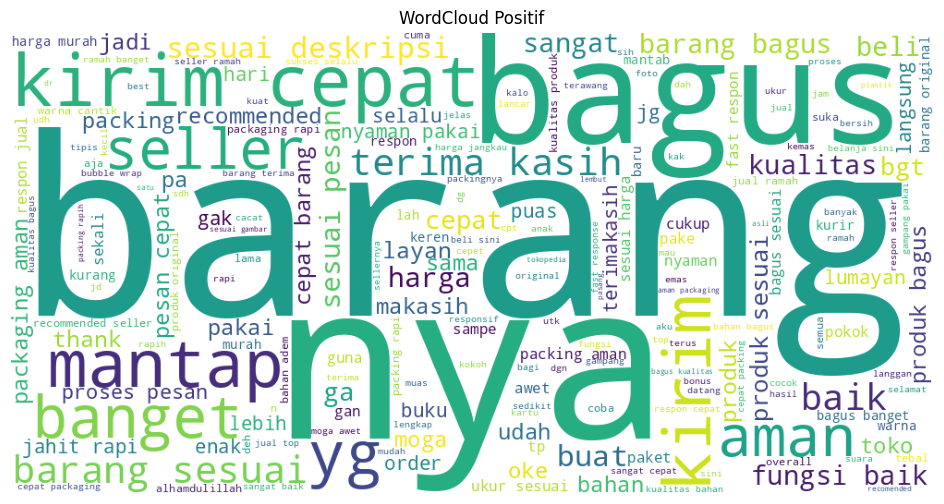

In [20]:
positive = df[
    df['Sentiment'] == 'Positive'
]

text = " ".join(positive['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("WordCloud Positif")

plt.show()

**WORDCLOUD NEGATIF**

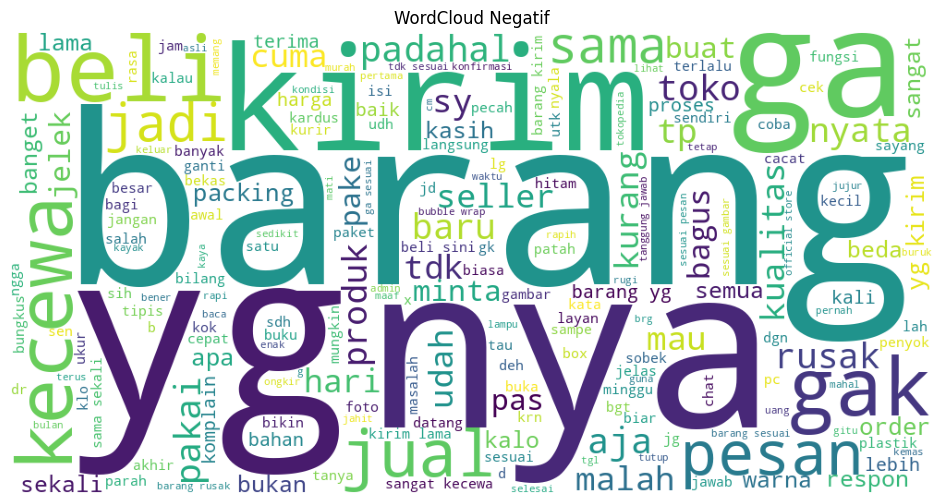

In [21]:
negative = df[
    df['Sentiment'] == 'Negative'
]

text = " ".join(negative['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("WordCloud Negatif")

plt.show()

# **TF-IDF**

In [22]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['clean_text']
)

y = df['Sentiment']

**SPLIT DATA**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**TRAINING MODEL**

In [24]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

**PREDIKSI**

In [25]:
y_pred = model.predict(X_test)

**ACCURACY**

In [26]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9148148148148149


**PRECISION**

In [27]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision :", precision)

Precision : 0.9150247991239737


**RECALL**

In [28]:
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall :", recall)

Recall : 0.9148148148148149


**F1 SCORE**

In [29]:
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score :", f1)

F1 Score : 0.9147656397945034


**CLASSIFICATION REPORT**

In [30]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.93      0.92       557
    Positive       0.92      0.90      0.91       523

    accuracy                           0.91      1080
   macro avg       0.92      0.91      0.91      1080
weighted avg       0.92      0.91      0.91      1080



**CONFUSION MATRIX**

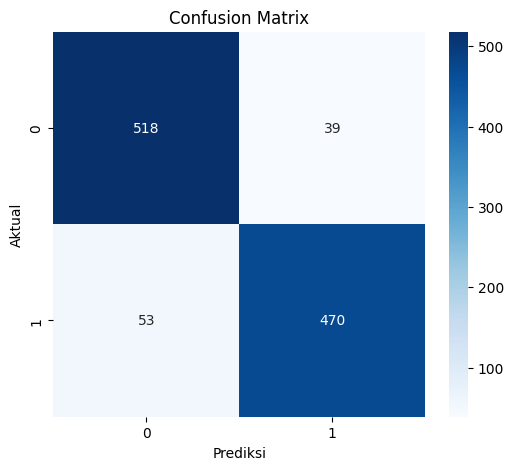

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

**PREDIKSI DATA BARU**

In [32]:
kalimat = [
    "produk sangat bagus dan pengiriman cepat, mantap"
]

kalimat = vectorizer.transform(kalimat)

hasil = model.predict(kalimat)

print("Sentimen :", hasil[0])

Sentimen : Positive


**Prediksi Data Baru 2**

In [33]:
kalimat = [
    "produk jelek, rusak, apalah tokonya aneh"
]

kalimat = vectorizer.transform(kalimat)

hasil = model.predict(kalimat)

print("Sentimen :", hasil[0])

Sentimen : Negative


**MENYIMPAN MODEL**

In [34]:
import pickle

pickle.dump(
    model,
    open("naive_bayes.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("tfidf.pkl","wb")
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


**DOWNLOAD MODEL**

In [35]:
from google.colab import files

files.download("naive_bayes.pkl")

files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>